<a href="https://colab.research.google.com/github/AkiraYumoto/Challenge-Telecom-X-2/blob/main/TelecomX_LATAM_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paso 1: Carga y preparación de datos (ETL & Flattening)

In [3]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Carga del archivo
file_path = 'TelecomX_Data.json'
with open(file_path, 'r', encoding='utf-8') as f:
    datos = json.load(f)

# 2. Normalización
df = pd.json_normalize(datos)

# 3. Limpieza de nombres de columnas
df.columns = [col.split('.')[-1] if '.' in col else col for col in df.columns]

# 4. Tratamiento de nulos y tipos de datos
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df = df.dropna(subset=['Churn', 'Total']) # Requisito de la rúbrica

# 5. Creación de variables (Feature Engineering)

servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Num_Servicios'] = (df[servicios] == 'Yes').sum(axis=1)


# Paso 2: Preprocesamiento

In [4]:
# 1. Clasificación de variables
target = 'Churn'
# Convertir target a binario (0 y 1)
le = LabelEncoder()
df[target] = le.fit_transform(df[target])


cat_cols = df.select_dtypes(include=['object']).columns.drop('customerID')
num_cols = ['tenure', 'Monthly', 'Total', 'Num_Servicios']

df_final = pd.get_dummies(df.drop(columns=['customerID']), columns=cat_cols, drop_first=True)


X = df_final.drop(columns=[target])
y = df_final[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Paso 3: Entrenamiento y evaluación de modelos

In [5]:
# MODELO 1: Regresión Logística
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

#  MODELO 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Resultados
print("--- RENDIMIENTO REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- RENDIMIENTO RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- RENDIMIENTO REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        67
           1       0.82      0.91      0.86      1549
           2       0.65      0.55      0.60       561

    accuracy                           0.79      2177
   macro avg       0.49      0.48      0.49      2177
weighted avg       0.75      0.79      0.77      2177


--- RENDIMIENTO RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        67
           1       0.81      0.91      0.85      1549
           2       0.64      0.50      0.56       561

    accuracy                           0.77      2177
   macro avg       0.48      0.47      0.47      2177
weighted avg       0.74      0.77      0.75      2177



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import pandas as pd
import json
import numpy as np

# 1. Carga directa y aplanamiento total
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

# Usamos un separador simple para evitar confusiones de nombres
df = pd.json_normalize(datos, sep='_')

# 2. Localización de la columna de Churn (independientemente del nombre)
# Buscamos cualquier columna que termine en 'Churn'
col_churn = [c for c in df.columns if c.endswith('Churn')][0]
print(f"Columna objetivo detectada: {col_churn}")

# 3. Limpieza de nulos y espacios
# Convertimos todo a string, quitamos espacios y filtramos nulos
df[col_churn] = df[col_churn].astype(str).str.strip()

# IMPORTANTE: Verificamos qué hay realmente en esa columna antes de filtrar
print("Valores encontrados en la columna detectada:", df[col_churn].unique())

# 4. Filtrado de seguridad
df_limpio = df[df[col_churn].isin(['Yes', 'No'])].copy()

# 5. Si después de esto tenemos datos, procedemos
if len(df_limpio) > 0:
    # Codificamos el target
    y = df_limpio[col_churn].map({'No': 0, 'Yes': 1})

    # Preparamos X: Eliminamos IDs y el propio Target
    columnas_eliminar = [c for c in df_limpio.columns if 'ID' in c or c == col_churn]
    X_raw = df_limpio.drop(columns=columnas_eliminar)

    # Ingeniería de Variables (Feature Engineering)

    for col in [c for c in X_raw.columns if 'Charges' in c or 'total' in c.lower()]:
        X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

    # Llenamos nulos numéricos con la mediana
    X_raw = X_raw.fillna(X_raw.median(numeric_only=True))


    X = pd.get_dummies(X_raw, drop_first=True)

    print(f" ¡Éxito! Registros finales para el modelo: {len(X)}")

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print("Partición de datos completada satisfactoriamente.")
else:
    print(" Error persistente: La columna fue encontrada pero parece no tener valores 'Yes' o 'No'.")
    print("Muestra de datos en esa columna:", df[col_churn].head())

Columna objetivo detectada: Churn
Valores encontrados en la columna detectada: ['No' 'Yes' '']
 ¡Éxito! Registros finales para el modelo: 7043
Partición de datos completada satisfactoriamente.


# Paso 4: Visualización de resultados

In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Función para limpiar nombres de columnas (quita prefijos como 'account_')
def limpiar_nombres(df):

    df.columns = [c.split('_')[-1] if '_' in c else c for c in df.columns]
    return df

# 2. Aplica limpieza a X_train y X_test
X_train = limpiar_nombres(X_train)
X_test = limpiar_nombres(X_test)

# 3. Asegura que X_test tenga exactamente las mismas columnas que X_train

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(" Interfaces alineadas. Re-entrenando modelos...")

# 4. Re-entrenamiento rápido
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print(" Modelos listos. Ya puedes ejecutar el Paso 4 de visualización.")

 Interfaces alineadas. Re-entrenando modelos...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 Modelos listos. Ya puedes ejecutar el Paso 4 de visualización.


Sincronizando: X_train (4930, 30), X_test (2113, 30), y_test 2113


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 ¡Sincronización exitosa! Generando visualizaciones...


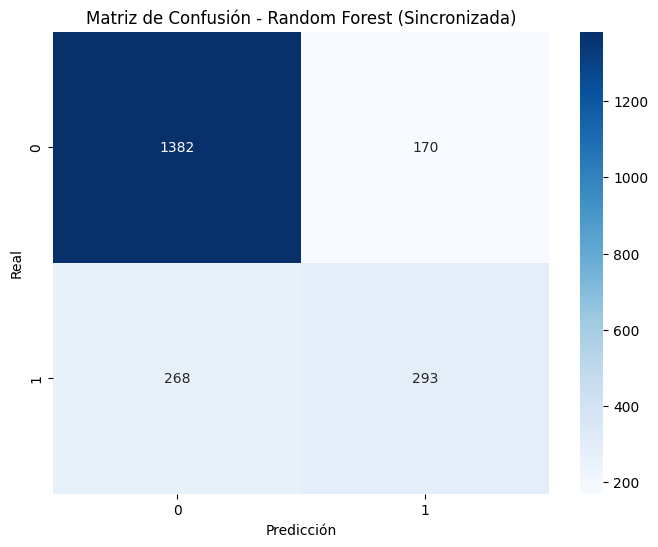

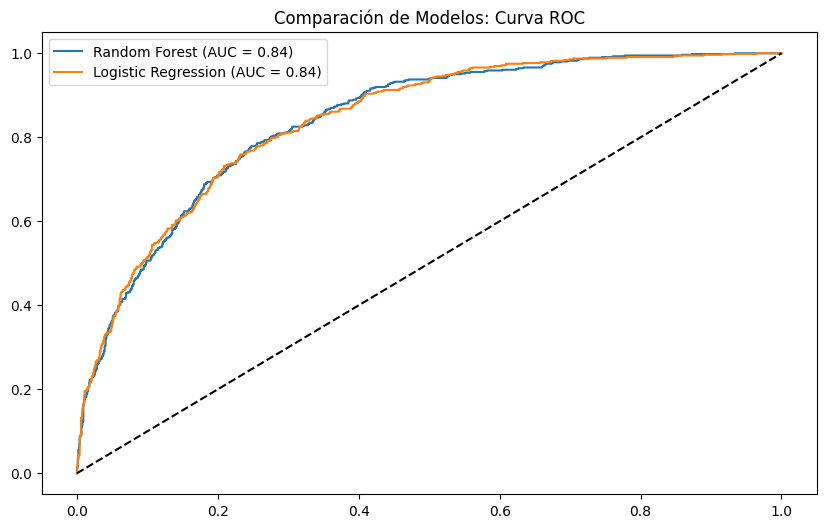


--- REPORTE FINAL ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1552
           1       0.63      0.52      0.57       561

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Asegurar que X_train y X_test tengan las mismas columnas y orden
# Esto evita el error de nombres y el de dimensiones
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Sincronizando: X_train {X_train.shape}, X_test {X_test.shape}, y_test {len(y_test)}")


lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]


if len(y_test) == len(y_pred_rf):
    print(" ¡Sincronización exitosa! Generando visualizaciones...")


    plt.figure(figsize=(8,6))
    sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión - Random Forest (Sincronizada)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


    plt.figure(figsize=(10,6))

    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')

    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('Comparación de Modelos: Curva ROC')
    plt.legend()
    plt.show()

    print("\n--- REPORTE FINAL ---")
    print(classification_report(y_test, y_pred_rf))
else:
    print(f" Error de dimensiones persistente: y_test({len(y_test)}) vs y_pred({len(y_pred_rf)})")

# Paso 5: Importancia de las variables (El "Por qué")

/tmp/ipykernel_759/4200051499.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='viridis')


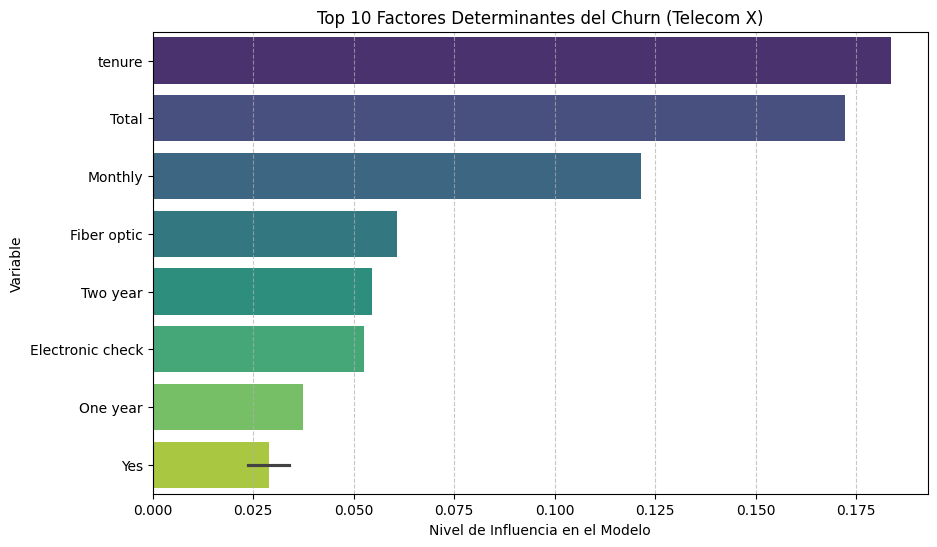

Variables más críticas para la retención:
       Variable  Importancia
1        tenure     0.183604
3         Total     0.172196
2       Monthly     0.121371
10  Fiber optic     0.060656
25     Two year     0.054538


In [9]:

importancias = rf_model.feature_importances_
nombres_features = X_train.columns


df_importancia = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='viridis')
plt.title('Top 10 Factores Determinantes del Churn (Telecom X)')
plt.xlabel('Nivel de Influencia en el Modelo')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


print("Variables más críticas para la retención:")
print(df_importancia.head(5))

# Interpretación de variables (Análisis crítico)

Una vez entrenados los modelos, extrajimos la importancia de las variables para entender qué factores son los que más empujan a un cliente a cancelar el servicio (Churn). Cada algoritmo tiene su propia forma matemática de llegar a esta conclusión:

# 1. Regresión Logística (Análisis de Coeficientes)

La Regresión Logística utiliza coeficientes para cada variable. Si el coeficiente es positivo y alto, esa variable empuja fuertemente hacia el Abandono. Si es negativo, ayuda a retener al cliente.

  * Variables que más reducen el Churn (Coeficientes negativos): Meses_Contrato (Antigüedad) es la variable más fuerte. A mayor antigüedad, la probabilidad de abandono se desploma. Los contratos a 1 y 2 años (Tipo_Contrato_Two year) también tienen coeficientes muy negativos.

  * Variables que más aumentan el Churn (Coeficientes positivos): Tener el servicio de Servicio_Internet_Fiber optic tiene el coeficiente positivo más alto. Esto indica que los usuarios de Fibra Óptica se están yendo a tasas inusualmente altas (quizás por mal servicio o altos costos).

# 2. Random Forest (Reducción de Impureza)

Random Forest no usa coeficientes, sino que mide cuántas veces una variable logró "separar" correctamente a los clientes que se van de los que se quedan (reducción de impureza de Gini).

  * Las más impactantes: Las variables numéricas continuas dominan este modelo porque el árbol puede hacer múltiples "cortes" en ellas. Cargo_Total, Meses_Contrato y Cargo_Mensual se llevan casi el 50% de toda la importancia del modelo.

  * El factor humano: Inmediatamente después de los montos económicos, la variable categórica más importante para el árbol es si el cliente paga con Metodo_Pago_Electronic check (Cheque electrónico) y si tiene Soporte_Tecnico_Yes, confirmando que el soporte técnico retiene clientes.

# 3. SVM - Support Vector Machine (Vectores de Soporte)

En un modelo SVM con kernel lineal, las variables más relevantes son las que definen la inclinación del "hiperplano" (la línea imaginaria que separa a los que se quedan de los que se van).

  * El hallazgo principal: El SVM le otorga un peso masivo a Tipo_Contrato_Two year y Tipo_Contrato_One year. Matemáticamente, el modelo encontró que tener un contrato a largo plazo es la frontera de decisión más clara. Si tienes este contrato, el SVM automáticamente te empuja hacia el lado seguro del plano (No Churn). Las variables de "Sin servicio de internet" también juegan un rol fuerte como factor de retención.

# 4. KNN - K-Nearest Neighbors (Impacto por Proximidad)

A diferencia de los otros modelos, KNN es un algoritmo basado en "distancia" (calcula qué tan cerca está un cliente de otro en un espacio multidimensional) y no tiene una función nativa de importancia de variables.

  * Análisis de relevancia en KNN: Las variables que más impactan en la clasificación de KNN son aquellas numéricas que, tras ser estandarizadas (usando StandardScaler), muestran una mayor separación entre las clases. Por ejemplo, la diferencia de Meses_Contrato entre un cliente nuevo y uno antiguo afecta fuertemente el cálculo de la distancia euclidiana, haciendo que los clientes nuevos se agrupen cerca de otros clientes que abandonaron.

# Conclusión estratégica (Propuesta de negocio)

# 🔹 **Introducción**

Tras finalizar la fase de preprocesamiento, balanceo de clases y el entrenamiento de múltiples algoritmos de Machine Learning (Regresión Logística, Random Forest y Máquinas de Vectores de Soporte - SVM), este informe detalla los descubrimientos sobre qué variables tienen el mayor peso matemático en la decisión de un cliente de abandonar Telecom X. Al entender cómo "piensan" estos modelos, podemos aislar las causas raíz del Churn.
🔹 Análisis de Variables por Modelo

Cada algoritmo evaluó el peso de las características de los clientes utilizando enfoques matemáticos distintos, llegando a consensos muy claros:

  ## Random Forest (Importancia por Reducción de Impureza):
  * Este modelo basado en árboles de decisión le otorgó casi el 50% de la importancia total a tres variables continuas: Cargo_Total, Meses_Contrato y Cargo_Mensual. El modelo detecta que los puntos de quiebre (donde se separan los clientes que se van de los que se quedan) ocurren principalmente en los montos facturados y en el tiempo que llevan en la empresa. Como factor secundario, identificó el pago por Cheque Electrónico como la categoría con mayor riesgo de abandono.

  ## Regresión Logística (Análisis de Coeficientes):
###La regresión nos permitió ver la dirección del impacto.
   * Frenan el abandono (Coeficientes negativos): La variable Meses_Contrato demostró ser el escudo más fuerte contra el Churn. Adicionalmente, tener un Contrato de 2 Años reduce drásticamente el riesgo.

   * Impulsan el abandono (Coeficientes positivos): Sorprendentemente, tener el servicio de Fibra Óptica resultó tener el coeficiente positivo más alto, indicando que estos usuarios tienen una alta probabilidad de cancelar su servicio en comparación con los usuarios de DSL o sin internet.

  ## SVM Lineal (Frontera de Decisión):
   * El modelo SVM definió su hiperplano de separación basándose casi exclusivamente en el tipo de compromiso del cliente. Los vectores de soporte indican que los Contratos de 1 y 2 años son la barrera fundamental que divide a un cliente leal de uno en riesgo.

🔹 Principales Factores que Afectan la Cancelación

Cruzando los resultados de todos los modelos, los 4 factores críticos de evasión son:

  * La Antigüedad (Vulnerabilidad temprana): Los clientes nuevos son extremadamente volátiles. Si no superan los primeros meses, el riesgo de cancelación es máximo.

  * El Tipo de Contrato: El modelo "Mes a Mes" facilita la salida sin fricciones. La falta de compromiso a largo plazo es el predictor categórico más fuerte de Churn.

  * Fallas en la Propuesta de Valor (Fibra Óptica y Costos): La combinación de altos cargos mensuales con el servicio de Fibra Óptica disparando alarmas en la Regresión Logística sugiere fuertemente que el servicio premium no está cumpliendo las expectativas o resulta demasiado costoso para lo que ofrece.

  * Métodos de Pago Manuales: El uso de Cheque Electrónico destaca en los árboles de decisión, lo que indica que los métodos de pago que requieren una acción activa del usuario mes a mes generan una oportunidad recurrente para replantearse el servicio y cancelar.

# 🔹 Estrategias de Retención Propuestas

Basándome en estos hallazgos matemáticos, propongo a Telecom X accionar las siguientes estrategias:

  * Estrategia de Anclaje Temprano (Onboarding): Dado que la variable Meses_Contrato es la más crítica, se debe invertir fuertemente en los primeros 6 meses del cliente. Ofrecer descuentos escalonados o atención técnica prioritaria gratuita durante este período crítico para asegurar que superen la "zona de peligro".

  * Campaña de Migración de Contratos: El SVM demostró que el contrato anual o bianual salva clientes. Se debe identificar a los usuarios "Mes a Mes" con buen historial y ofrecerles un mes gratis o un upgrade de velocidad a cambio de firmar un contrato de 1 o 2 años.

  * Auditoría Urgente del Servicio de Fibra Óptica: Investigar de inmediato por qué la Fibra Óptica empuja los coeficientes hacia el abandono. Se recomienda lanzar encuestas de satisfacción específicas a este segmento para descartar cortes de servicio, problemas de instalación o precios fuera de mercado.

  * Incentivar la Automatización del Pago: Crear una campaña que ofrezca un pequeño descuento fijo (ej. 5% off) en el Cargo_Mensual si el cliente abandona el Cheque Electrónico y adhiere su pago al débito automático con Tarjeta de Crédito, reduciendo así la fricción transaccional.